In [61]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [62]:
#Define Hyperparameters
USE_URL       = "https://tfhub.dev/google/universal-sentence-encoder/4" # DAN version
BATCH_SIZE    = 32
EPOCHS        = 10
LEARNING_RATE = 1e-4
LSTM_UNITS    = 100
N_FOLDS       = 5
RANDOM_SEED   = 42
OUTPUT_DIR    = "use_results"
CLASS_NAMES   = ["Denier", "Believer"]

In [63]:
#Define paths for climate stance data
CLIMATE_DATA_CSV = r"C:\Users\chouh\OneDrive\Desktop\VirginiaTech\Spring 2026\SocialMediaAnalytics\FinalProject\archive\twitter_sentiment_data.csv"

df = pd.read_csv(CLIMATE_DATA_CSV)
df = df.dropna(subset=["message"])
stance_df = df[df["sentiment"].isin([-1, 1])].copy()
stance_df["stance_label"] = stance_df["sentiment"].map({-1: 0, 1: 1})

#Preprocessing
def preprocess_text(texts):
    texts = texts.str.replace(r"http\S+|www\.\S+", "", regex=True)   # remove URLs
    texts = texts.str.replace(r"@\w+", "", regex=True)               # remove @mentions
    texts = texts.str.replace(r"RT\s+", "", regex=True)               # remove RT tag
    texts = texts.str.replace(r"\s+", " ", regex=True).str.strip()    # remove whitespace
    return texts

stance_df["clean_text"] = preprocess_text(stance_df["message"])

print(f"Climate Data Filtered: {len(stance_df):,} samples.")
print(f"  Denier  : {(stance_df['stance_label'] == 0).sum():,}  ({(stance_df['stance_label'] == 0).mean()*100:.1f}%)")
print(f"  Believer: {(stance_df['stance_label'] == 1).sum():,}  ({(stance_df['stance_label'] == 1).mean()*100:.1f}%)")

Climate Data Filtered: 26,952 samples.
  Denier  : 3,990  (14.8%)
  Believer: 22,962  (85.2%)


In [64]:
#Generated with help of Claude - Universal Sentence Encoder
use_model = hub.load(USE_URL)

def encode_texts(texts, batch_size=256):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        emb = use_model(texts[i: i + batch_size]).numpy()
        embeddings.append(emb)
    return np.vstack(embeddings)

In [65]:
#Sarcasm Data Preparation and Feature Encoding (Generated with help of Claude)
SARCASM_CSV = r"C:\Users\chouh\OneDrive\Desktop\VirginiaTech\Spring 2026\SocialMediaAnalytics\FinalProject\archive\train.En.csv"
isarcasm_df = pd.read_csv(SARCASM_CSV)

X_sarcasm = encode_texts(isarcasm_df["tweet"].astype(str).tolist())
X_sarcasm_seq = np.expand_dims(X_sarcasm, axis=1)  # (N, 1, 512)
y_sarcasm = isarcasm_df["sarcastic"].values

In [66]:
#Sarcasm Feature Learning (Generated with help of Claude & Gemini)
s_inp = tf.keras.Input(shape=(1, 512))
s_bilstm_layer = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(LSTM_UNITS, return_sequences=False), name="sarcasm_bilstm"
)(s_inp)
s_drop = tf.keras.layers.Dropout(0.3)(s_bilstm_layer)
s_out = tf.keras.layers.Dense(1, activation='sigmoid')(s_drop)

s_expert = tf.keras.Model(s_inp, s_out)
s_expert.compile(optimizer='adam', loss='binary_crossentropy', metrics=["accuracy"])
s_expert.fit(X_sarcasm_seq, y_sarcasm, epochs=5, batch_size=32,
             validation_split=0.15, verbose=1)

sarcasm_weights = s_expert.get_layer("sarcasm_bilstm").get_weights()
print("Sarcasm Knowledge Captured.")

Epoch 1/5
93/93 [==============================] - 9s 69ms/step - loss: 0.6240 - accuracy: 0.7007 - val_loss: 0.3435 - val_accuracy: 1.0000
Epoch 2/5
93/93 [==============================] - 7s 79ms/step - loss: 0.5893 - accuracy: 0.7058 - val_loss: 0.3426 - val_accuracy: 1.0000
Epoch 3/5
93/93 [==============================] - 5s 53ms/step - loss: 0.5707 - accuracy: 0.7078 - val_loss: 0.3458 - val_accuracy: 0.9904
Epoch 4/5
93/93 [==============================] - 5s 55ms/step - loss: 0.5558 - accuracy: 0.7211 - val_loss: 0.3325 - val_accuracy: 0.9674
Epoch 5/5
93/93 [==============================] - 5s 56ms/step - loss: 0.5465 - accuracy: 0.7313 - val_loss: 0.3165 - val_accuracy: 0.9482
Sarcasm Knowledge Captured.


In [67]:
X_stance = encode_texts(stance_df["clean_text"].tolist())
X_stance_seq = np.expand_dims(X_stance, axis=1)
y_stance = stance_df["stance_label"].values

print(f"Stance embedding shape: {X_stance_seq.shape}")


Stance embedding shape: (26952, 1, 512)


In [68]:
#Sarcasm initialized stance classifier (Generated with help of Claude)
def build_stance_model():
    inp = tf.keras.Input(shape=(1, 512), name="use_input")

    bilstm_layer = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(LSTM_UNITS, return_sequences=False),
        name="bilstm_stance"
    )
    x = bilstm_layer(inp)

    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid', name="stance_output")(x)

    model = tf.keras.Model(inputs=inp, outputs=out)

    # Transfer sarcasm weights into this stance model
    model.get_layer("bilstm_stance").set_weights(sarcasm_weights)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [69]:
#Stratified 5-Fold Cross-Validation (Generated with help of Claude)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

fold_accs = []
fold_macro_f1s = []
fold_weighted_f1s = []
fold_macro_precs = []
fold_macro_recs = []
fold_cls_f1s = []
fold_y_tests = []
fold_y_preds = []

print("=" * 60)
print(f"  Stratified {N_FOLDS}-Fold Cross-Validation")
print("=" * 60)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_stance_seq, y_stance), 1):
    print(f"\n--- FOLD {fold}/{N_FOLDS} ---")

    X_train, X_test = X_stance_seq[train_idx], X_stance_seq[test_idx]
    y_train, y_test = y_stance[train_idx], y_stance[test_idx]

    print(f"  Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}")

    # Class weights for THIS fold's training data
    classes = np.unique(y_train)
    wts = compute_class_weight("balanced", classes=classes, y=y_train)
    cw = dict(zip(classes.astype(int), wts))

    # Fresh model with sarcasm weights
    model = build_stance_model()

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        class_weight=cw,
        callbacks=[early_stop],
        verbose=1,
    )
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    mf1 = f1_score(y_test, y_pred, average="macro")
    wf1 = f1_score(y_test, y_pred, average="weighted")
    mpr = precision_score(y_test, y_pred, average="macro")
    mrc = recall_score(y_test, y_pred, average="macro")
    cf1 = f1_score(y_test, y_pred, average=None)

    fold_accs.append(acc)
    fold_macro_f1s.append(mf1)
    fold_weighted_f1s.append(wf1)
    fold_macro_precs.append(mpr)
    fold_macro_recs.append(mrc)
    fold_cls_f1s.append(cf1)
    fold_y_tests.append(y_test)
    fold_y_preds.append(y_pred)

    print(f"  Fold {fold}: Acc={acc*100:.2f}%  Macro-F1={mf1*100:.2f}%  "
      f"F1-Denier={cf1[0]*100:.2f}%  F1-Believer={cf1[1]*100:.2f}%")


  Stratified 5-Fold Cross-Validation

--- FOLD 1/5 ---
  Train: 21,561   Test: 5,391
Epoch 1/10
607/607 [==============================] - 43s 68ms/step - loss: 0.6199 - accuracy: 0.7112 - val_loss: 0.5152 - val_accuracy: 0.7863
Epoch 2/10
607/607 [==============================] - 41s 68ms/step - loss: 0.5049 - accuracy: 0.7578 - val_loss: 0.4664 - val_accuracy: 0.7747
Epoch 3/10
607/607 [==============================] - 33s 54ms/step - loss: 0.4696 - accuracy: 0.7725 - val_loss: 0.4553 - val_accuracy: 0.7770
Epoch 4/10
607/607 [==============================] - 33s 54ms/step - loss: 0.4528 - accuracy: 0.7800 - val_loss: 0.4452 - val_accuracy: 0.7779
Epoch 5/10
607/607 [==============================] - 32s 53ms/step - loss: 0.4460 - accuracy: 0.7811 - val_loss: 0.4205 - val_accuracy: 0.7988
Epoch 6/10
607/607 [==============================] - 33s 54ms/step - loss: 0.4391 - accuracy: 0.7882 - val_loss: 0.4319 - val_accuracy: 0.7891
Epoch 7/10
607/607 [==============================]

In [70]:
#Evaluation Metrics (Generated with help of Claude)
cls_f1_arr = np.array(fold_cls_f1s)

print("\n" + "=" * 60)
print(f"  {N_FOLDS}-FOLD CROSS-VALIDATION RESULTS (Mean +/- Std)")
print("=" * 60)
print(f"  Accuracy        : {np.mean(fold_accs)*100:.2f}% +/- {np.std(fold_accs)*100:.2f}%")
print(f"  Macro-F1        : {np.mean(fold_macro_f1s)*100:.2f}% +/- {np.std(fold_macro_f1s)*100:.2f}%  <-- primary")
print(f"  Weighted-F1     : {np.mean(fold_weighted_f1s)*100:.2f}% +/- {np.std(fold_weighted_f1s)*100:.2f}%")
print(f"  Macro-Precision : {np.mean(fold_macro_precs)*100:.2f}% +/- {np.std(fold_macro_precs)*100:.2f}%")
print(f"  Macro-Recall    : {np.mean(fold_macro_recs)*100:.2f}% +/- {np.std(fold_macro_recs)*100:.2f}%")
print(f"  F1-Denier       : {cls_f1_arr[:,0].mean()*100:.2f}% +/- {cls_f1_arr[:,0].std()*100:.2f}%")
print(f"  F1-Believer     : {cls_f1_arr[:,1].mean()*100:.2f}% +/- {cls_f1_arr[:,1].std()*100:.2f}%")
print("=" * 60)

# Per-fold table (Generated with help of Claude)
fold_table = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(fold_accs))],   # ← fixed
    "Accuracy": [round(a*100, 2) for a in fold_accs],
    "Macro-F1": [round(f*100, 2) for f in fold_macro_f1s],
    "F1-Denier": [round(c[0]*100, 2) for c in fold_cls_f1s],
    "F1-Believer": [round(c[1]*100, 2) for c in fold_cls_f1s],
})
print("\n")
print(fold_table.to_string(index=False))


  5-FOLD CROSS-VALIDATION RESULTS (Mean +/- Std)
  Accuracy        : 80.41% +/- 0.46%
  Macro-F1        : 70.32% +/- 0.52%  <-- primary
  Weighted-F1     : 82.50% +/- 0.37%
  Macro-Precision : 67.99% +/- 0.43%
  Macro-Recall    : 78.04% +/- 0.59%
  F1-Denier       : 53.02% +/- 0.76%
  F1-Believer     : 87.62% +/- 0.32%


  Fold  Accuracy  Macro-F1  F1-Denier  F1-Believer
Fold 1     80.76     70.54      53.18        87.90
Fold 2     80.00     69.65      51.92        87.38
Fold 3     79.93     69.89      52.50        87.27
Fold 4     81.11     71.13      54.14        88.11
Fold 5     80.24     70.41      53.35        87.47


In [71]:
#Evaluation Metrics (Generated with help of Claude)
all_y_test = np.concatenate(fold_y_tests)
all_y_pred = np.concatenate(fold_y_preds)

print("\nAggregated Classification Report (all folds combined):")
print(classification_report(all_y_test, all_y_pred,
                            target_names=CLASS_NAMES, digits=4))


Aggregated Classification Report (all folds combined):
              precision    recall  f1-score   support

      Denier     0.4110    0.7466    0.5302      3990
    Believer     0.9487    0.8141    0.8762     22962

    accuracy                         0.8041     26952
   macro avg     0.6799    0.7804    0.7032     26952
weighted avg     0.8691    0.8041    0.8250     26952



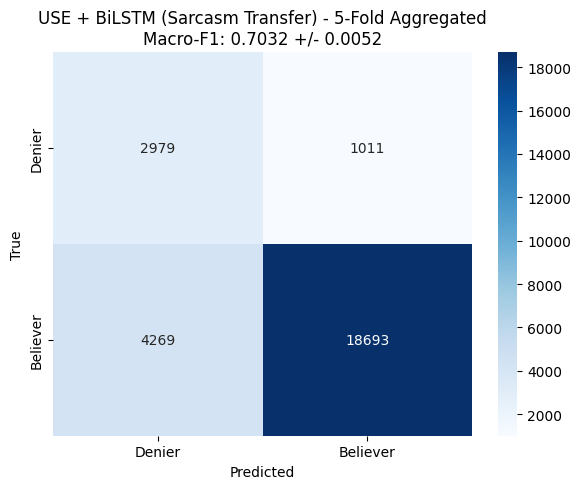

In [72]:
#Confusion Matrix (Generated with help of Claude)
cm = confusion_matrix(all_y_test, all_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"USE + BiLSTM (Sarcasm Transfer) - {N_FOLDS}-Fold Aggregated\n"
             f"Macro-F1: {np.mean(fold_macro_f1s):.4f} +/- {np.std(fold_macro_f1s):.4f}")
plt.tight_layout()
plt.show()